# Carga e Ingesta de Datos (Data understanding)

In [42]:
import pandas as pd

df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   paciente_id               1400 non-null   object 
 1   sucursal                  1400 non-null   object 
 2   especie                   1400 non-null   object 
 3   raza_registrada           1400 non-null   int64  
 4   edad_mascota_anios        1400 non-null   float64
 5   tipo_atencion             1400 non-null   object 
 6   diagnostico_texto         1400 non-null   object 
 7   medico_id                 1400 non-null   object 
 8   monto_cobrado             1400 non-null   int64  
 9   costo_medicamento         1379 non-null   float64
 10  dias_desde_ultima_visita  1400 non-null   int64  
 11  visitas_historicas        1400 non-null   int64  
 12  tiene_vacunas_al_dia      1400 non-null   int64  
 13  retorno_90d               1400 non-null   int64  
dtypes: float

# Limpieza de encoding y tratamiento de nulos

In [43]:
# Instalamos ftfy, librería para arreglar desastres de encoding
!pip install ftfy

In [54]:
import pandas as pd
from ftfy import fix_text

# Volvemos a cargar el archivo original para partir de cero y limpio
df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

# Definimos una función que usa ftfy y luego pasa a minúsculas
def clean_vetsur_text(text):
    if pd.isna(text):
        return text
    # fix_text arregla monstruos como 'Ã ua±oa' a 'Ñuñoa' automáticamente
    cleaned_text = fix_text(str(text))
    # Luego pasamos a minúsculas y quitamos espacios extra
    return cleaned_text.lower().strip()

# Aplicamos la función a las columnas con problemas
cols_to_fix = ['sucursal', 'tipo_atencion', 'diagnostico_texto']
for col in cols_to_fix:
    df[col] = df[col].apply(clean_vetsur_text)

# Rellenar los nulos de costo con la mediana
df['costo_medicamento'] = df['costo_medicamento'].fillna(df['costo_medicamento'].median())

# Verificamos la tablita final
df[['sucursal', 'tipo_atencion', 'diagnostico_texto', 'costo_medicamento']].head(10)

,sucursal,tipo_atencion,diagnostico_texto,costo_medicamento
0,providencia,consulta_general,control_rutina,3500.0
1,ñuñoa,hospitalización,tumor,34600.0
2,peñalolén,hospitalización,control_rutina,31100.0
3,las_condes,consulta_especialidad,control_rutina,24700.0
4,ñuñoa,consulta_general,dermatitis,5800.0
5,peñalolén,consulta_general,fractura,4800.0
6,providencia,cirugía,artritis,74800.0
7,san_miguel,consulta_especialidad,artrítís,17600.0
8,la_florida,consulta_especialidad,esterilización,7500.0
9,pudahuel,cirugía,tumor_c,95100.0


## Normalización estándar (sin tildes ni eñes)

In [55]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    # convertimos a string, quitamos espacios y pasamos a minusculas
    texto = str(texto).lower().strip()
    # eliminamos tildes y caracteres especiales (como la ñ) de forma tecnica
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

# aplicamos la normalizacion a todas las columnas de texto
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].apply(normalizar_texto)

# verificamos que ahora todo sea texto plano (ej: nunoa, cirugia, maipu)
print("columnas normalizadas exitosamente.")
print(df['sucursal'].unique())
print("tipos de atencion limpios:")
print(df['tipo_atencion'].unique())

print("\nespecies limpias:")
print(df['especie'].unique())

columnas normalizadas exitosamente.
['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']
tipos de atencion limpios:
['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']

especies limpias:
['gato' 'perro' 'ave' 'exa³tico']


In [61]:
df['especie'] = df['especie'].str.replace('exa³tico', 'exotico', case=False, regex=False)

print("especies limpias (ahora si que si):")
print(df['especie'].unique())

especies limpias (ahora si que si):
['gato' 'perro' 'ave' 'exotico']


# 3. Análisis exploratorio (EDA)

## Bloque 1: Distribución del target objetivo (retorno_90d)

/tmp/ipykernel_2520/1646130484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)


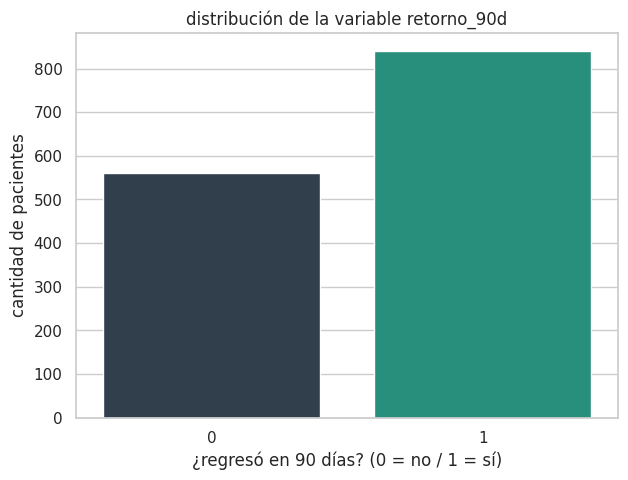

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# paleta consistente para todo el informe
vetsur_palette = ["#2c3e50", "#16a085"]

plt.figure(figsize=(7,5))
sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)

plt.title('distribución de la variable retorno_90d', fontsize=12)
plt.xlabel('¿regresó en 90 días? (0 = no / 1 = sí)')
plt.ylabel('cantidad de pacientes')
plt.show()

## Bloque 2: Matriz de correlación (relación entre variables)

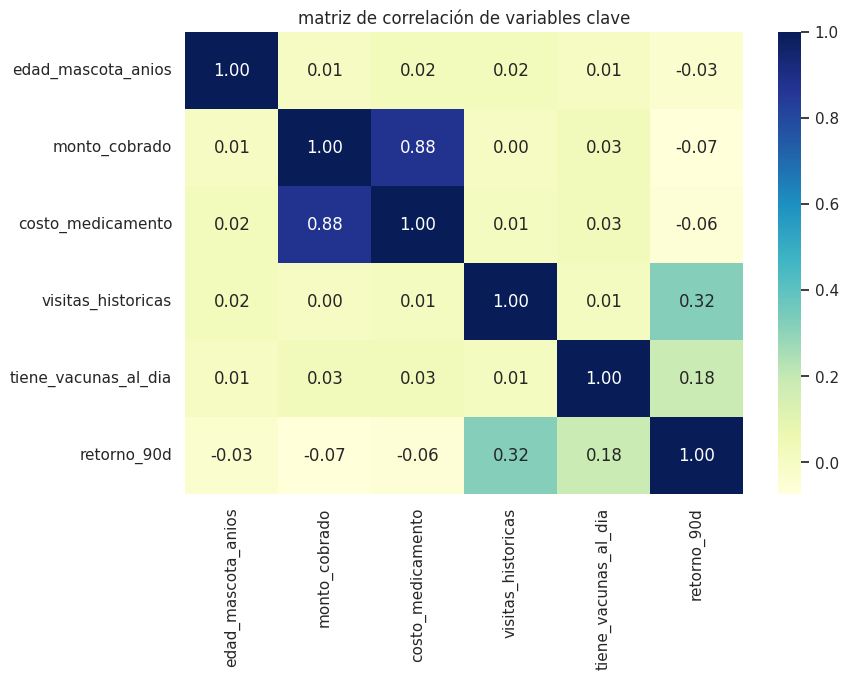

In [46]:
# seleccionamos solo las columnas con valor financiero y operativo
columnas_estudio = [
    'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento',
    'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d'
]

plt.figure(figsize=(9,6))
# usamos un mapa de colores que mantenga la consistencia (YlGnBu)
sns.heatmap(df[columnas_estudio].corr(), annot=True, cmap='YlGnBu', fmt=".2f")

plt.title('matriz de correlación de variables clave', fontsize=12)
plt.show()

## Bloque 3: Hallazgo de negocio (vacunas vs retorno)


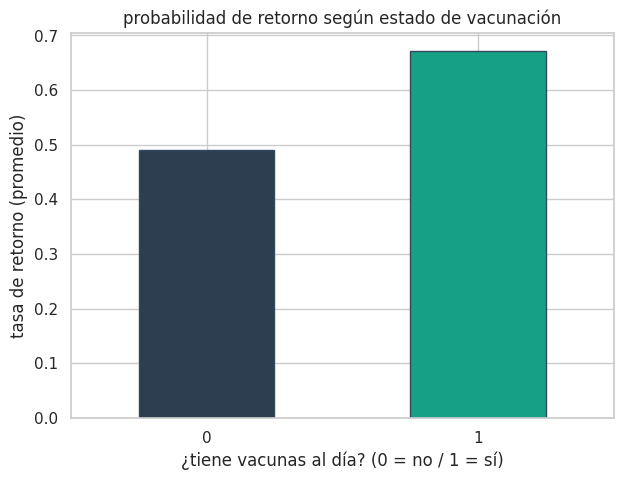

In [47]:
plt.figure(figsize=(7,5))

# graficamos el promedio de retorno agrupado por vacunas
df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean().plot(
    kind='bar',
    color=vetsur_palette,
    edgecolor='#34495e'
)

plt.title('probabilidad de retorno según estado de vacunación', fontsize=12)
plt.xlabel('¿tiene vacunas al día? (0 = no / 1 = sí)')
plt.ylabel('tasa de retorno (promedio)')
plt.xticks(rotation=0)
plt.show()

# 4. Feature engineering

## Auditoría final de normalización

In [67]:
columnas_chequeo = ['sucursal', 'especie', 'tipo_atencion']

print("--- REVISIÓN DE CATEGORÍAS ---")
for col in columnas_chequeo:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

# buscamos si queda algún caracter que no sea letra, número o espacio
import re
def tiene_caracter_raro(texto):
    if pd.isna(texto): return False
    return bool(re.search(r'[^a-zA-Z0-9\s_]', str(texto)))

print("\n" + "="*30)
print("--- BUSCADOR DE CARÁCTERES BASURA---")
for col in columnas_chequeo:
    errores = df[df[col].apply(tiene_caracter_raro)][col].unique()
    if len(errores) > 0:
        print(f"Se encontró algo en '{col}': {errores}")
    else:
        print(f"'{col}' está 100% limpia.")

--- REVISIÓN DE CATEGORÍAS ---

Valores únicos en 'sucursal':
['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']

Valores únicos en 'especie':
['gato' 'perro' 'ave' 'exotico']

Valores únicos en 'tipo_atencion':
['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']

--- BUSCADOR DE CARÁCTERES BASURA---
'sucursal' está 100% limpia.
'especie' está 100% limpia.
'tipo_atencion' está 100% limpia.


In [68]:
# con esto ves cuántas especies distintas hay y cuántas veces se repiten
# al tener solo 4 categorías limpias (perro, gato, ave, exotico), nos aseguramos de que el modelo entienda perfectamente que solo existen esos 4 grupos.
df['especie'].value_counts()

,count
especie,
perro,802
gato,451
ave,90
exotico,57


## One-Hot Encoding

In [70]:
# con esto revisamos el "alma" de cada columna antes de transformarla
for col in df.columns:
    print(f"--- Columna: {col} ---")
    print(f"Tipo de dato: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")

    # si es texto, mostramos los valores únicos para ver si hay mas 'memes'
    if df[col].dtype == 'object':
        print(f"Valores únicos: {df[col].unique()}")
    else:
        # si es numero, mostramos el rango para ver si hay valores locos
        print(f"Rango: min={df[col].min()} | max={df[col].max()}")
    print("\n")

--- Columna: paciente_id ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['pac_00419' 'pac_00001' 'pac_00002' ... 'pac_01396' 'pac_01398'
 'pac_01399']


--- Columna: sucursal ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']


--- Columna: especie ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['gato' 'perro' 'ave' 'exotico']


--- Columna: raza_registrada ---
Tipo de dato: int64
Nulos: 0
Rango: min=0 | max=1


--- Columna: edad_mascota_anios ---
Tipo de dato: float64
Nulos: 0
Rango: min=0.1 | max=18.0


--- Columna: tipo_atencion ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']


--- Columna: diagnostico_texto ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['control_rutina' 'tumor' 'dermatitis' 'fractura' 'artritis'
 'esterilizacion' 'tumor_c' 'artritis_c' 'gastroenteritis' 'fractura_c'
 'oti

In [71]:
import pandas as pd

# Borramos los IDs que dijimos que no sirven (para evitar el overfitting)
df_limpio = df.drop(columns=['paciente_id', 'medico_id'])

# Aplicamos el One-Hot Encoding a las columnas de texto
# Esto crea las columnas de 0 y 1 para sucursal, especie, etc.
df_final = pd.get_dummies(df_limpio, columns=['sucursal', 'especie', 'tipo_atencion', 'diagnostico_texto'], drop_first=True)

# Verificamos que ahora todo sea numérico
print("Columnas después del One-Hot Encoding:")
print(df_final.columns.tolist())
print(f"\nAhora tenemos {df_final.shape[1]} columnas listas para el modelo.")
df_final.head()

Columnas después del One-Hot Encoding:
['raza_registrada', 'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento', 'dias_desde_ultima_visita', 'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d', 'sucursal_las_condes', 'sucursal_maipu', 'sucursal_nunoa', 'sucursal_penalolen', 'sucursal_providencia', 'sucursal_pudahuel', 'sucursal_san_miguel', 'especie_exotico', 'especie_gato', 'especie_perro', 'tipo_atencion_consulta_especialidad', 'tipo_atencion_consulta_general', 'tipo_atencion_hospitalizacion', 'tipo_atencion_venta_producto', 'diagnostico_texto_artritis_c', 'diagnostico_texto_control_rutina', 'diagnostico_texto_control_rutina_c', 'diagnostico_texto_dermatitis', 'diagnostico_texto_dermatitis_c', 'diagnostico_texto_diabetes', 'diagnostico_texto_diabetes_c', 'diagnostico_texto_esterilizacion', 'diagnostico_texto_esterilizacion_c', 'diagnostico_texto_fractura', 'diagnostico_texto_fractura_c', 'diagnostico_texto_gastroenteritis', 'diagnostico_texto_gastroenteritis_c', 'diagno

,raza_registrada,edad_mascota_anios,monto_cobrado,costo_medicamento,dias_desde_ultima_visita,visitas_historicas,tiene_vacunas_al_dia,retorno_90d,sucursal_las_condes,sucursal_maipu,...,diagnostico_texto_fractura,diagnostico_texto_fractura_c,diagnostico_texto_gastroenteritis,diagnostico_texto_gastroenteritis_c,diagnostico_texto_otitis,diagnostico_texto_otitis_c,diagnostico_texto_parvovirus,diagnostico_texto_parvovirus_c,diagnostico_texto_tumor,diagnostico_texto_tumor_c
0,0,4.7,38900,3500.0,462,3,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0.6,234200,34600.0,112,2,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.1,147800,31100.0,42,4,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,5.9,82600,24700.0,187,5,1,0,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,0.9,36300,5800.0,111,7,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False


In [72]:
# con esto veo qué columnas quedaron y si son todas numéricas
print("--- INFO DEL DATASET FINAL ---")
print(df_final.info())

print("\n--- PRIMERAS 5 FILAS ---")
print(df_final.head())

--- INFO DEL DATASET FINAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   raza_registrada                      1400 non-null   int64  
 1   edad_mascota_anios                   1400 non-null   float64
 2   monto_cobrado                        1400 non-null   int64  
 3   costo_medicamento                    1400 non-null   float64
 4   dias_desde_ultima_visita             1400 non-null   int64  
 5   visitas_historicas                   1400 non-null   int64  
 6   tiene_vacunas_al_dia                 1400 non-null   int64  
 7   retorno_90d                          1400 non-null   int64  
 8   sucursal_las_condes                  1400 non-null   bool   
 9   sucursal_maipu                       1400 non-null   bool   
 10  sucursal_nunoa                       1400 non-null   bool   
 11 

# Modelo predictivo y evaluación

## Random forest

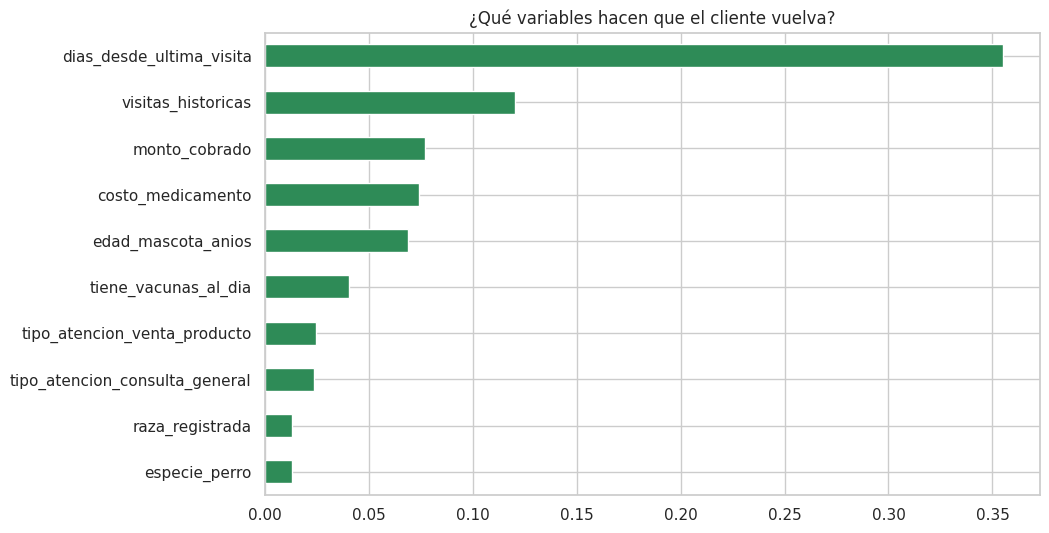

Precisión del modelo: 0.85


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Definimos X (datos) e y (objetivo)
X = df_final.drop(columns=['retorno_90d'])
y = df_final['retorno_90d']

# 2. Dividimos 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamos el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Graficamos la importancia para el informe
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias.head(10).plot(kind='barh', color='seagreen')
plt.title('¿Qué variables hacen que el cliente vuelva?')
plt.gca().invert_yaxis()
plt.show()

# 5. La nota final
print(f"Precisión del modelo: {modelo.score(X_test, y_test):.2f}")

## Comparativa con alternativas

In [81]:
predicciones_bosque = modelo.predict(X_test)

# Regresión simple
modelo_lineal = LogisticRegression(max_iter=5000)
modelo_lineal.fit(X_train, y_train)
predicciones_lineal = modelo_lineal.predict(X_test)

# Gradient boosting
modelo_boosting = GradientBoostingClassifier(random_state=42)
modelo_boosting.fit(X_train, y_train)
predicciones_boosting = modelo_boosting.predict(X_test)

print("--- RESULTADOS COMPARADOS ---")
print(f"Random forest     -> Acc: {accuracy_score(y_test, predicciones_bosque):.2f} | Recall: {recall_score(y_test, predicciones_bosque):.2f}")
print(f"Modelo lineal     -> Acc: {accuracy_score(y_test, predicciones_lineal):.2f} | Recall: {recall_score(y_test, predicciones_lineal):.2f}")
print(f"Boosting          -> Acc: {accuracy_score(y_test, predicciones_boosting):.2f} | Recall: {recall_score(y_test, predicciones_boosting):.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- RESULTADOS COMPARADOS ---
Random forest     -> Acc: 0.85 | Recall: 0.90
Modelo lineal     -> Acc: 0.84 | Recall: 0.86
Boosting          -> Acc: 0.84 | Recall: 0.87


## Validación cruzada

In [84]:
from sklearn.model_selection import cross_val_score

puebas_acc = cross_val_score(modelo, X, y, cv=5)
pruebas_recall = cross_val_score(modelo, X, y, cv=5, scoring='recall')

print("RESULTADOS VALIDACIÓN CRUZADA")
print(f"Accuracy en cada prueba: {puebas_acc}")
print(f"Promedio accuracy: {puebas_acc.mean():.2f}")
print("-" * 40)
print(f"Recall en cada prueba: {pruebas_recall}")
print(f"Promedio recall: {pruebas_recall.mean():.2f}")

RESULTADOS VALIDACIÓN CRUZADA
Accuracy en cada prueba: [0.82857143 0.85714286 0.83928571 0.87857143 0.85357143]
Promedio accuracy: 0.85
----------------------------------------
Recall en cada prueba: [0.91666667 0.88095238 0.89880952 0.91071429 0.875     ]
Promedio recall: 0.90
